# Advanced:  Shiny Gray Decks in Eclipse Geometry

This notebook assumes familiarity with clouds and emission in POSEIDON. 

In this advanced tutorial, we display the 'shiny' deck. This model allows for gray opaque cloud decks to be parameterized with a top-most albedo (i.e., the top of the deck has an albedo).

These models are meant to emulate the reality that opaque cloud decks have non-zero albedos (e.g., think of Jupiter's top-most cloud deck, which has an intrinsic albedo and color in visible wavelengths).

This model is near-identical to the constant albedo surface featured in the 'Surfaces' tutorial, but here it applied to gas giants and brown dwarfs.

All cloud models that have a gray deck included in them now have a 'shiny' option that allows them to have a new free parameter, albedo_deck. 

## Example: HD 189733b Secondary Eclipse

Here we use HD 189733b as a test case. The forward model here matches the 'Reflection in Hot Jupiters' example, except it tests all cloud models that have a gray opaque deck included in them, and explictly showcases the 'shiny' variant. 

In [1]:
from POSEIDON.constants import R_Sun, R_J, M_J
from POSEIDON.core import create_star, create_planet, load_data, define_model, \
                          wl_grid_constant_R, set_priors, read_opacities
from POSEIDON.visuals import plot_data, plot_spectra_retrieved, plot_PT_retrieved
from POSEIDON.retrieval import run_retrieval
from POSEIDON.utility import read_retrieved_spectrum, read_retrieved_PT, \
                             read_retrieved_log_X, plot_collection
from POSEIDON.corner import generate_cornerplot

import numpy as np
from scipy.constants import au
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.2     # Minimum wavelength (um)
wl_max = 5     # Maximum wavelength (um)
R = 1000         # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl_1 = np.linspace(wl_min, 1.0, 1000)[:-1]
wl_2 = wl_grid_constant_R(1.0, wl_max, R)
wl_2 = wl_2[1:]    # Indexing to avoid 1.0 um being repeated twice
wl = np.concatenate((wl_1, wl_2))

#***** Define planet properties *****#

planet_name = 'HD 189733b'  # Planet name used for plots, output files etc.

R_p = 1.13*R_J    # Planetary radius (m)
M_p = 1.129*M_J
d = 19.7638*pc
#d_err = 0.005*pc # Error in a priori system distance
a_p = 0.03142*au

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, a_p = a_p)


#***** Define stellar properties *****#

R_s = 0.78*R_Sun      # Stellar radius (m)
T_s = 5014         # Stellar effective temperature (K)
Met_s = 0.13          # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] <--- note: for PHOENIX, only the solar metallicity models are used  
log_g_s = 4.58       # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

In order to define a shiny deck model, just add 'shiny_' in front of the normal cloud_type string. 

Gray Opaque Deck: 

deck -> shiny_deck 

Below, we also define the normal opaque gray deck to be patchy, so we can explore how cloud coverage changes the resultant spectra. 

Mie Scattering Aerosol Fuzzy Deck: 

fuzzy_deck -> shiny_fuzzy_deck 

Mie Scattering Aerosol Uniform Mixing Ratio + Opaque Deck: 

opaque_deck_plus_uniform_X -> shiny_opaque_deck_plus_uniform_X

Mie Scattering Aerosol Slab + Opaque Deck: 

opaque_deck_plus_slab -> shiny_opaque_deck_plus_slab

Mie Scattering Aerosol Slab + Fuzzy Deck: 

fuzzy_deck_plus_slab -> shiny_fuzzy_deck_plus_slab

In [2]:
#***** Define model *****#

model_name_shiny_deck = 'Patchy_Shiny_Deck'

#***** Define model *****#

bulk_species = ['H2', 'He']
param_species = ['CO', 'CO2', 'H2O', 'K','Na',]

# Create the model object
model_shiny_deck = define_model(model_name_shiny_deck, bulk_species, param_species, 
                     PT_profile = 'Guillot_dayside',
                     cloud_model = 'MacMad17',cloud_type = 'shiny_deck',
                     thermal = True, thermal_scattering = True, reflection = True, 
                     Na_K_fixed_ratio = True,
                     cloud_dim = 2)

model_name = 'Shiny_Fuzzy_Deck_SiO2'

# Set aerosol species
aerosol_species = ['SiO2']  # <---- Put aerosol species here

# Define model
model_shiny_fuzzy_deck = define_model(model_name, bulk_species, param_species,
                                PT_profile = 'Guillot_dayside', X_profile = 'isochem',
                                cloud_model = 'Mie',                 # <---- Put cloud model here (Mie)
                                cloud_type = 'shiny_fuzzy_deck',           # <---- Put cloud type here 
                                aerosol_species = aerosol_species,   # <---- Put aerosol species list here 
                                thermal = True, thermal_scattering = True, reflection = True, 
                                Na_K_fixed_ratio = True,
                                )   

model_name = 'Shiny_Opaque_deck_plus_uniform_X'

aerosol_species = ['SiO2'] # <---- Put aerosol species here

model_shiny_deck_UX = define_model(model_name, bulk_species, param_species,
                                        PT_profile = 'Guillot_dayside', X_profile = 'isochem',
                                        cloud_model = 'Mie',cloud_type = 'shiny_opaque_deck_plus_uniform_X', # <---- Put cloud type here 
                                        aerosol_species = aerosol_species,
                                        thermal = True, thermal_scattering = True, reflection = True, 
                                        Na_K_fixed_ratio = True,
                                        ) # <---- Put aerosol species list here 

model_name = 'Shiny_Opaque_deck_plus_slab'

aerosol_species = ['SiO2'] # <---- Put aerosol species here

model_shiny_deck_slab = define_model(model_name, bulk_species, param_species,
                                        PT_profile = 'Guillot_dayside', X_profile = 'isochem',
                                        cloud_model = 'Mie',cloud_type = 'shiny_opaque_deck_plus_slab', # <---- Put cloud type here 
                                        aerosol_species = aerosol_species,
                                        thermal = True, thermal_scattering = True, reflection = True, 
                                        Na_K_fixed_ratio = True,
                                        ) # <---- Put aerosol species list here 

model_name = 'Shiny_Fuzzy_Deck_Slab_Fe_SiO2'

# Set aerosol species
aerosol_species = ['Fe','SiO2']  # <---- Put aerosol species here

# Define model
model_shiny_fuzzy_deck_slab = define_model(model_name, bulk_species, param_species,
                                PT_profile = 'Guillot_dayside', X_profile = 'isochem',
                                cloud_model = 'Mie',                 # <---- Put cloud model here (Mie)
                                cloud_type = 'shiny_fuzzy_deck_plus_slab',           # <---- Put cloud type here 
                                aerosol_species = aerosol_species,   # <---- Put aerosol species list here 
                                thermal = True, thermal_scattering = True, reflection = True, 
                                Na_K_fixed_ratio = True,
                                )  


print(model_shiny_deck['param_names'])
print(model_shiny_fuzzy_deck['param_names'])
print(model_shiny_deck_UX['param_names'])
print(model_shiny_deck_slab['param_names'])
print(model_shiny_fuzzy_deck_slab['param_names'])

This mode assumes that the first aerosol in the list is the deck species, rest are slab species
['R_p_ref' 'log_kappa_IR' 'log_gamma' 'T_int' 'T_equ' 'log_CO' 'log_CO2'
 'log_H2O' 'log_Na' 'log_P_cloud' 'albedo_deck' 'phi_cloud']
['R_p_ref' 'log_kappa_IR' 'log_gamma' 'T_int' 'T_equ' 'log_CO' 'log_CO2'
 'log_H2O' 'log_Na' 'albedo_deck' 'log_P_top_deck_SiO2' 'log_r_m_SiO2'
 'log_n_max_SiO2' 'f_SiO2']
['R_p_ref' 'log_kappa_IR' 'log_gamma' 'T_int' 'T_equ' 'log_CO' 'log_CO2'
 'log_H2O' 'log_Na' 'albedo_deck' 'log_P_top_deck' 'log_r_m_SiO2'
 'log_X_SiO2']
['R_p_ref' 'log_kappa_IR' 'log_gamma' 'T_int' 'T_equ' 'log_CO' 'log_CO2'
 'log_H2O' 'log_Na' 'albedo_deck' 'log_P_top_deck' 'log_P_top_slab_SiO2'
 'Delta_log_P_SiO2' 'log_r_m_SiO2' 'log_X_SiO2']
['R_p_ref' 'log_kappa_IR' 'log_gamma' 'T_int' 'T_equ' 'log_CO' 'log_CO2'
 'log_H2O' 'log_Na' 'albedo_deck' 'log_P_top_deck_Fe' 'log_r_m_Fe'
 'log_n_max_Fe' 'f_Fe' 'log_P_top_slab_SiO2' 'Delta_log_P_SiO2'
 'log_r_m_SiO2' 'log_X_SiO2']


Now we load in the cross sections.

In [3]:
#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100    # Same as prior range for T
T_fine_max = 3000    # Same as prior range for T
T_fine_step = 20     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-6   # 10 nbar
P_max = 100       # 10 bar
N_layers = 100   # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 1   # Retrieved R_p_ref parameter will be the radius at 10 bar

#***** Run atmospheric retrieval *****#
opac = read_opacities(model_shiny_deck, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
CO2-H2 done
CO2-CO2 done
CO done
CO2 done
H2O done
Na done
K done
Opacity pre-interpolation complete.


Need to add Mie scattering aerosols to the opac object seperately. 

In [4]:
# Add the aerosols above to the opac object 
from POSEIDON.clouds import switch_aerosol_in_opac

opac_sio2_aerosols = switch_aerosol_in_opac(model_shiny_fuzzy_deck, opac)
opac_fe_sio2_aerosols = switch_aerosol_in_opac(model_shiny_fuzzy_deck_slab, opac)

Reading in database for aerosol cross sections...
Reading in database for aerosol cross sections...


Since this is an advanced tutorial, we will go ahead and define all the atmosphere objects in a single cell. 

In [5]:
from POSEIDON.core import make_atmosphere

R_p_ref               =   1.12 * R_J

# PT Params
log_kappa_IR          =   -4.82 
log_gamma             =   -0.42 
T_int                 =   255.7 
T_equ                 =   1159.5

# Gas Phase Mixing Ratios
log_CO                =   -5.30 
log_CO2               =   -3.07 
log_H2O               =   -5.33  
log_Na                =   -6.59 

# Gray Deck Parameters
log_P_cloud = -1
albedo_deck = 0.5
phi_cloud = 1

# Fuzzy Deck Parameters
log_P_top_deck_SiO2 = 0     # <---- Top of the opaque deck is at 1 bar (extends from 100 to 1 bar)
log_r_m_SiO2        = -2    # <---- Mean particle size of the SiO2 aerosols is 1e-2 microns
log_n_max_SiO2      = 10    # <---- The number density of SiO2 at the top of the opaque deck (at 1 bar)
f_SiO2              = 0.3   # <---- The fuzziness of aerosols (how number density evolves above the cloud deck)

# Slab Parameters
log_P_top_slab_SiO2 = -5  # <---- The top of the slab in pressure space (at 1e-5 bars)
Delta_log_P_SiO2    = 2   # <---- Extend of the slab in pressure space (extends down to 1e-3 bars)
log_r_m_SiO2        = -2  # <---- Mean particle size of the SiO2 aerosols is 1e-2 microns
log_X_SiO2          = -12 # <---- Volume mixing ratio of aerosol in the slab (1e-5 to 1e-3 bars)


PT_params = np.array([log_kappa_IR, log_gamma, T_int, T_equ])
log_X_params = np.array([log_CO, log_CO2, log_H2O, log_Na,])

# Shiny Opaque Deck 
cloud_params = np.array([log_P_cloud, albedo_deck, phi_cloud])

atmosphere_shiny_deck = make_atmosphere(planet, model_shiny_deck, P, P_ref, R_p_ref, 
                                              PT_params, log_X_params, cloud_params)

# Shiny SiO2 Fuzzy Deck 
cloud_params = np.array([albedo_deck, log_P_top_deck_SiO2, log_r_m_SiO2, log_n_max_SiO2, f_SiO2])

atmosphere_shiny_fuzzy_deck = make_atmosphere(planet, model_shiny_fuzzy_deck, P, P_ref, R_p_ref, 
                                              PT_params, log_X_params, cloud_params)

# Shiny Opaque Deck + SiO2 Uniform Mixing Ratio Aerosols
cloud_params = np.array([albedo_deck, log_P_cloud, log_r_m_SiO2 ,log_X_SiO2])

atmosphere_shiny_deck_ux = make_atmosphere(planet, model_shiny_deck_UX, P, P_ref, R_p_ref, 
                                              PT_params, log_X_params, cloud_params)

# Shiny Opaque Deck + SiO2 Slab
cloud_params = np.array([albedo_deck,log_P_cloud, log_P_top_slab_SiO2, Delta_log_P_SiO2, log_r_m_SiO2 ,log_X_SiO2])

atmosphere_shiny_deck_slab = make_atmosphere(planet, model_shiny_deck_slab, P, P_ref, R_p_ref, 
                                              PT_params, log_X_params, cloud_params)

# Shiny SiO2 Fuzzy Deck + Fe Slab
cloud_params = np.array([albedo_deck, log_P_top_deck_SiO2, log_r_m_SiO2, log_n_max_SiO2, f_SiO2,
                         log_P_top_slab_SiO2, Delta_log_P_SiO2, log_r_m_SiO2 ,log_X_SiO2])

atmosphere_shiny_fuzzy_deck_slab = make_atmosphere(planet, model_shiny_fuzzy_deck_slab, P, P_ref, R_p_ref, 
                                                   PT_params, log_X_params, cloud_params)

Now lets compute some spectra! 

In [6]:
from POSEIDON.core import compute_spectrum

Fp_Fs_shiny_deck = compute_spectrum(planet, star, model_shiny_deck, atmosphere_shiny_deck, opac, wl, 
                                          spectrum_type = 'emission') 

In [7]:
# Remember to use opac_sio2_aerosols here 

Fp_Fs_shiny_fuzzy_deck = compute_spectrum(planet, star, model_shiny_fuzzy_deck, atmosphere_shiny_fuzzy_deck, 
                                          opac_sio2_aerosols, wl, 
                                          spectrum_type = 'emission') 


In [8]:
# Remember to use opac_sio2_aerosols here 

Fp_Fs_shiny_deck_ux = compute_spectrum(planet, star, model_shiny_deck_UX, atmosphere_shiny_deck_ux, 
                                       opac_sio2_aerosols, wl, 
                                       spectrum_type = 'emission') 

In [9]:
# Remember to use opac_sio2_aerosols here 

Fp_Fs_shiny_deck_slab = compute_spectrum(planet, star, model_shiny_deck_slab, atmosphere_shiny_deck_slab,
                                          opac_sio2_aerosols, wl, 
                                          spectrum_type = 'emission') 

In [10]:
# Remember to use opac_fe_sio2_aerosols here 

Fp_Fs_shiny_fuzzy_deck_slab = compute_spectrum(planet, star, model_shiny_fuzzy_deck_slab, atmosphere_shiny_fuzzy_deck_slab, 
                                               opac_fe_sio2_aerosols, wl, 
                                               spectrum_type = 'emission') 

Generate the plots

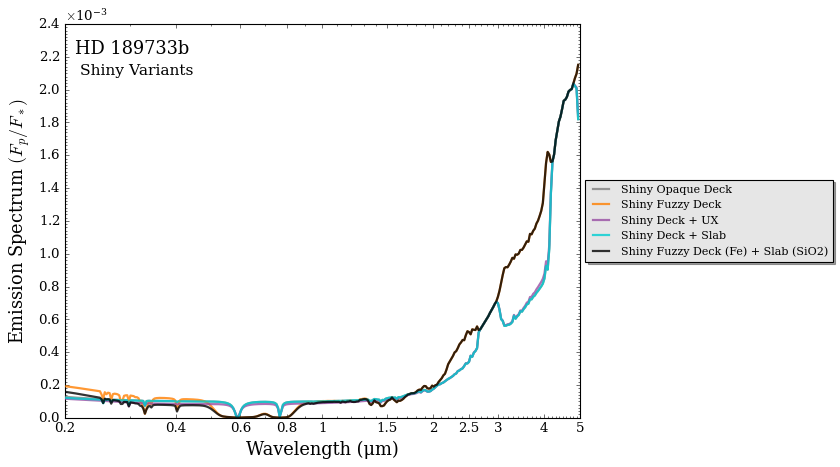

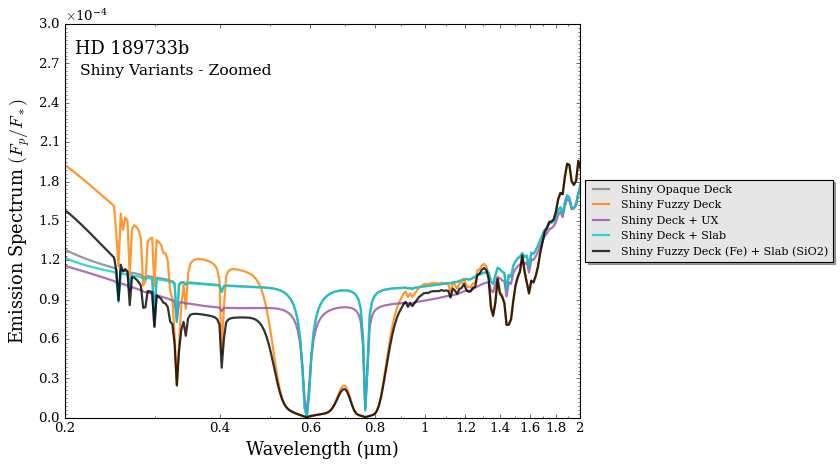

In [11]:
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

spectra = []

# Add the model spectra to the plot collection object
spectra = plot_collection(Fp_Fs_shiny_deck, wl, collection = spectra)
spectra = plot_collection(Fp_Fs_shiny_fuzzy_deck, wl, collection = spectra)
spectra = plot_collection(Fp_Fs_shiny_deck_ux, wl, collection = spectra)
spectra = plot_collection(Fp_Fs_shiny_deck_slab, wl, collection = spectra)
spectra = plot_collection(Fp_Fs_shiny_fuzzy_deck_slab, wl, collection = spectra)

# Plot spectra
title = 'Shiny Variants'

# Produce figure 
fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        y_unit = 'eclipse_depth', spectra_labels = ['Shiny Opaque Deck','Shiny Fuzzy Deck','Shiny Deck + UX', 'Shiny Deck + Slab', 'Shiny Fuzzy Deck (Fe) + Slab (SiO2)'],
                        legend_location = 'outside right', wl_axis = 'log', colour_list = ['gray', '#ff7f00', '#984ea3', 'darkturquoise', 'black'],
                        plt_label = title,
                        figure_shape = 'wide')

# Produce figure
title = 'Shiny Variants - Zoomed'

fig_spec = plot_spectra(spectra, planet, R_to_bin = 100, plot_full_res = False,
                        y_unit = 'eclipse_depth', spectra_labels = ['Shiny Opaque Deck','Shiny Fuzzy Deck','Shiny Deck + UX', 'Shiny Deck + Slab', 'Shiny Fuzzy Deck (Fe) + Slab (SiO2)'],
                        legend_location = 'outside right', wl_axis = 'log', colour_list = ['gray', '#ff7f00', '#984ea3', 'darkturquoise', 'black'],
                        plt_label = title,
                        figure_shape = 'wide',
                        wl_max = 2, y_max = 0.3e-3)

## Shiny Opaque Deck Parameter Exploration

Lets just look at how changing the free parameters of the shiny opaque deck (without Mie scattering aerosols) changes the resulting spectra.

In [12]:
R_p_ref               =   1.12 * R_J

log_kappa_IR          =   -4.82 
log_gamma             =   -0.42 
T_int                 =   255.7 
T_equ                 =   1159.5

log_CO                =   -5.30 
log_CO2               =   -3.07 
log_H2O               =   -5.33  
log_Na                =   -6.59 

log_P_cloud = -1
albedo_deck = 0.5
phi_cloud = 1


PT_params = np.array([log_kappa_IR, log_gamma, T_int, T_equ])

log_X_params = np.array([log_CO, log_CO2, log_H2O, log_Na,])

cloud_params = np.array([log_P_cloud, albedo_deck, phi_cloud])


Lets vary cloud coverage percentage

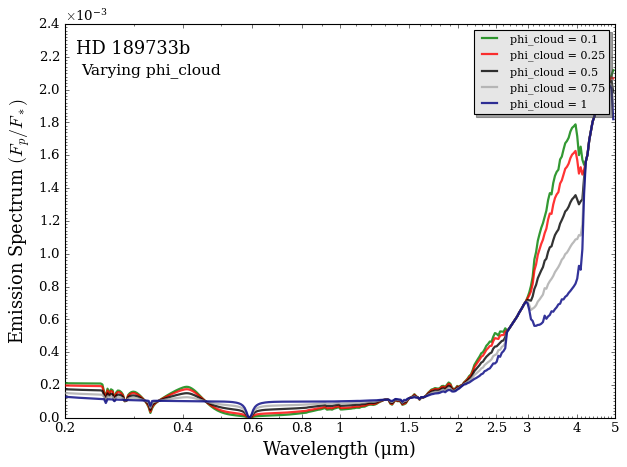

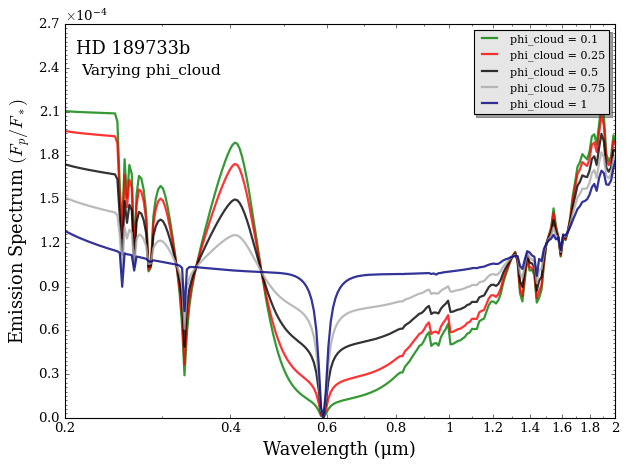

In [18]:
from POSEIDON.clouds import vary_one_parameter

param_name = 'phi_cloud'
vary_list = [0.1, 0.25, 0.5, 0.75, 1]


vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs')

vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs', y_max = 2.7e-4, wl_max = 2)

Vary the albedo of the deck. 

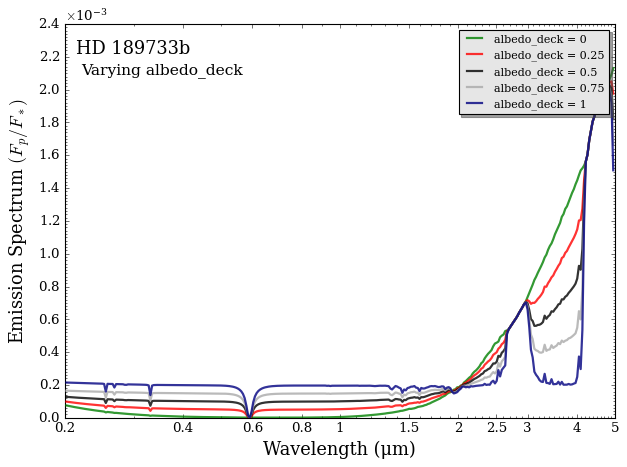

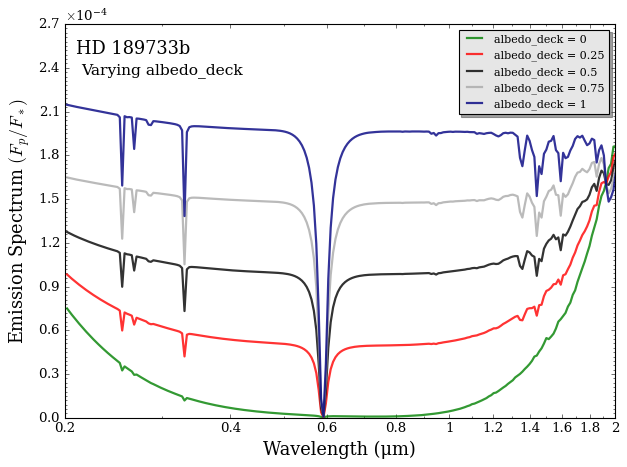

In [19]:
#from POSEIDON.clouds import vary_one_parameter

param_name = 'albedo_deck'
vary_list = [0,0.25, 0.5, 0.75, 1]

vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs')

vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs', y_max = 2.7e-4, wl_max = 2)

Vary the deck top pressure

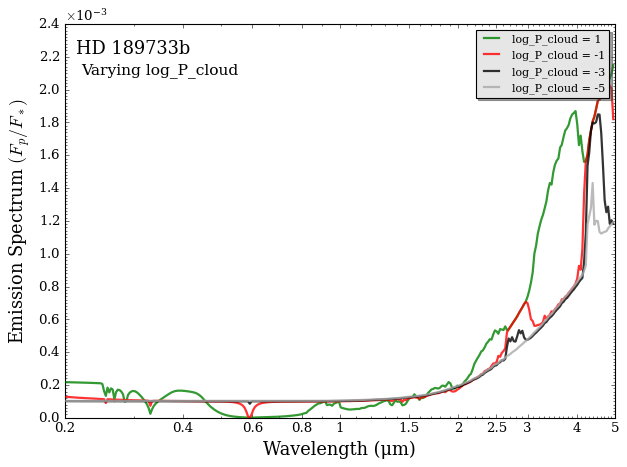

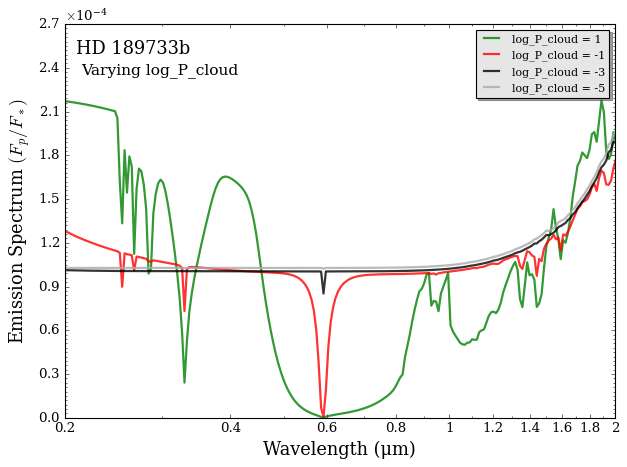

In [17]:
#from POSEIDON.clouds import vary_one_parameter

param_name = 'log_P_cloud'
vary_list = [1,-1,-3,-5]

vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs')

vary_one_parameter(model_shiny_deck, planet, star, param_name, vary_list,
                       wl, opac, P, P_ref, R_p_ref, PT_params, log_X_params, cloud_params,
                       spectrum_type = 'emission', y_unit = 'Fp/Fs', wl_max = 2, y_max = 2.7e-4)